
# Linear Models I & II – Lecture Notebook

This notebook connects **Week I (linear regression + loss + gradient descent)** to **Week II (logistic regression + classification + regularization)**.

We will use **two datasets**:

- **Diabetes (sklearn)**: continuous outcome → *linear regression*
- **Iris (sklearn)**: 3-class outcome → *multinomial logistic regression*

Goals:
1. Fit linear regression, visualize loss (L2) meaningfully
2. Show **Gradient Descent (GD)** vs **Stochastic GD (SGD)** behavior
3. Fit multiclass logistic regression and compute **logistic loss (cross-entropy)**
4. Show how **L1 regularization** can drive some feature weights to **exactly zero**
5. Visualize **decision boundaries** for logistic regression (2D slice)

> Tip: Run cells top-to-bottom. Randomness in SGD is controlled with a fixed seed for reproducibility.


## 0. Setup

In [20]:

import numpy as np
import matplotlib.pyplot as plt

from sklearn import datasets
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import log_loss

np.random.seed(42)



## 1. Linear Regression (Continuous Target)

We start with a regression task: predict a **continuous** outcome.

We use the **Diabetes** dataset:
- **Target**: disease progression measure (continuous)
- **Features**: 10 baseline variables

To keep visuals simple and interpretable, we use **one feature** (so we can plot the data and a fitted line).


In [21]:

diabetes = datasets.load_diabetes()
feature_names_diabetes = diabetes.feature_names
target_name_diabetes = "disease progression (continuous)"

# Pick 1 feature for simple visualization
feat_idx = 2  # "bmi" in the sklearn diabetes dataset
X_raw = diabetes.data[:, feat_idx:feat_idx+1]
y = diabetes.target

print("Dataset: Diabetes")
print("Using feature index:", feat_idx, "name:", feature_names_diabetes[feat_idx])
print("Target:", target_name_diabetes)
print("X shape:", X_raw.shape, "y shape:", y.shape)

# Scale the feature for optimization stability
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)


Dataset: Diabetes
Using feature index: 2 name: bmi
Target: disease progression (continuous)
X shape: (442, 1) y shape: (442,)



### Fit a Linear Regression Model

Model:

\[
\hat{y} = wx + b
\]

We fit the model with sklearn (closed-form / analytic solution for OLS in this simple setting).


In [22]:

lin_reg = LinearRegression()
lin_reg.fit(X, y)

w_hat = float(lin_reg.coef_[0])
b_hat = float(lin_reg.intercept_)

print("Fitted parameters (OLS):")
print("  w =", w_hat)
print("  b =", b_hat)


Fitted parameters (OLS):
  w = 45.16003002046289
  b = 152.13348416289594


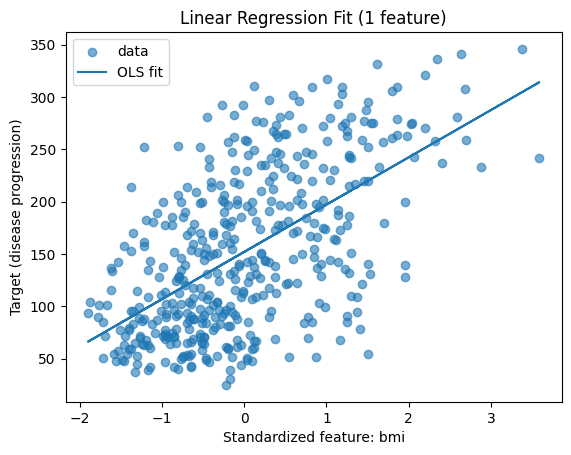

In [23]:

plt.figure()
plt.scatter(X, y, alpha=0.6, label="data")
plt.plot(X, lin_reg.predict(X), label="OLS fit")
plt.title("Linear Regression Fit (1 feature)")
plt.xlabel(f"Standardized feature: {feature_names_diabetes[feat_idx]}")
plt.ylabel("Target (disease progression)")
plt.legend()
plt.show()



## 2. L2 Loss: A More Informative Visualization

Instead of plotting loss only against **w** while keeping **b fixed**, we visualize the **loss surface** over both parameters:


$\mathcal{L}(w,b) = \frac{1}{n}\sum_{i=1}^n (y_i - (wx_i + b))^2$

A contour plot makes the geometry clearer and shows why gradient descent "slides downhill" toward a minimum.


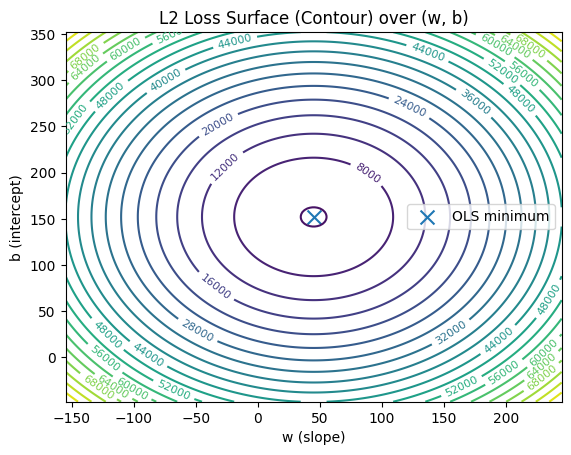

In [24]:

x = X.flatten()

def l2_loss_wb(w, b):
    y_pred = w * x + b
    return np.mean((y - y_pred) ** 2)

# Grid for (w, b)
w_grid = np.linspace(w_hat - 200, w_hat + 200, 200)
b_grid = np.linspace(b_hat - 200, b_hat + 200, 200)

W, B = np.meshgrid(w_grid, b_grid)
L = np.zeros_like(W)

for i in range(W.shape[0]):
    for j in range(W.shape[1]):
        L[i, j] = l2_loss_wb(W[i, j], B[i, j])

plt.figure()
cs = plt.contour(W, B, L, levels=25)
plt.clabel(cs, inline=True, fontsize=8)
plt.scatter([w_hat], [b_hat], marker="x", s=100, label="OLS minimum")
plt.title("L2 Loss Surface (Contour) over (w, b)")
plt.xlabel("w (slope)")
plt.ylabel("b (intercept)")
plt.legend()
plt.show()



## 3. Gradient Descent vs Stochastic Gradient Descent (GD vs SGD)

**GD** uses the gradient computed from **all** observations each step.

**SGD** uses the gradient from **one randomly-chosen** observation each step (noisy but fast).

We will:
1. Plot their **parameter trajectories** on the same loss contour
2. Plot **loss vs iteration** to show smooth vs noisy convergence


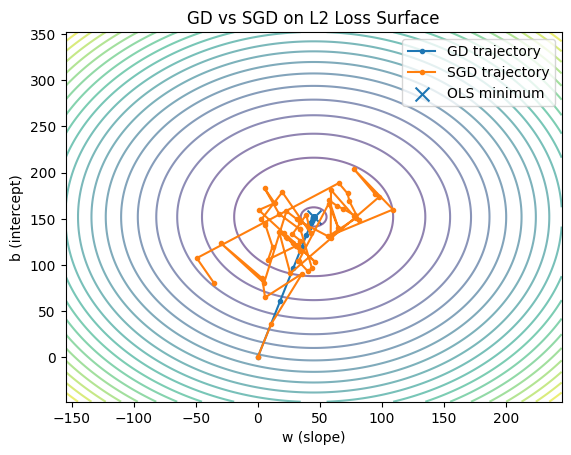

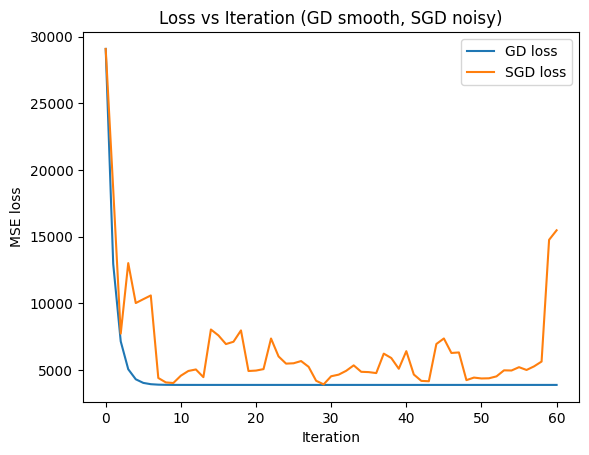

In [25]:

# Gradients for MSE = mean((y - (wx+b))^2)
def grad_mse(w, b):
    y_pred = w * x + b
    err = (y_pred - y)
    dw = 2 * np.mean(err * x)
    db = 2 * np.mean(err)
    return dw, db

def grad_mse_single(w, b, i):
    y_pred = w * x[i] + b
    err = (y_pred - y[i])
    dw = 2 * err * x[i]
    db = 2 * err
    return dw, db

# Initialize away from optimum so movement is visible
w0, b0 = 0.0, 0.0
eta = 0.2
steps = 60

# --- GD
w_gd, b_gd = w0, b0
traj_gd = [(w_gd, b_gd)]
loss_gd = [l2_loss_wb(w_gd, b_gd)]

for _ in range(steps):
    dw, db = grad_mse(w_gd, b_gd)
    w_gd -= eta * dw
    b_gd -= eta * db
    traj_gd.append((w_gd, b_gd))
    loss_gd.append(l2_loss_wb(w_gd, b_gd))

# --- SGD
w_sgd, b_sgd = w0, b0
traj_sgd = [(w_sgd, b_sgd)]
loss_sgd = [l2_loss_wb(w_sgd, b_sgd)]

rng = np.random.default_rng(42)
for _ in range(steps):
    i = rng.integers(0, len(x))
    dw, db = grad_mse_single(w_sgd, b_sgd, i)
    w_sgd -= eta * dw
    b_sgd -= eta * db
    traj_sgd.append((w_sgd, b_sgd))
    loss_sgd.append(l2_loss_wb(w_sgd, b_sgd))

traj_gd = np.array(traj_gd)
traj_sgd = np.array(traj_sgd)

# Plot trajectories on loss contour
plt.figure()
plt.contour(W, B, L, levels=25, alpha=0.6)
plt.plot(traj_gd[:,0], traj_gd[:,1], marker="o", markersize=3, label="GD trajectory")
plt.plot(traj_sgd[:,0], traj_sgd[:,1], marker="o", markersize=3, label="SGD trajectory")
plt.scatter([w_hat], [b_hat], marker="x", s=100, label="OLS minimum")
plt.title("GD vs SGD on L2 Loss Surface")
plt.xlabel("w (slope)")
plt.ylabel("b (intercept)")
plt.legend()
plt.show()

# Plot loss vs iteration
plt.figure()
plt.plot(loss_gd, label="GD loss")
plt.plot(loss_sgd, label="SGD loss")
plt.title("Loss vs Iteration (GD smooth, SGD noisy)")
plt.xlabel("Iteration")
plt.ylabel("MSE loss")
plt.legend()
plt.show()



## 4. Logistic Regression (Multi-class Classification)

Now we switch to classification.

We use the **Iris** dataset:
- **Target**: 3 flower species (3 classes)
- **Features**: 4 measurements

To visualize decision boundaries, we use **two features** (2D).


In [26]:

iris = datasets.load_iris()
X_iris_raw = iris.data
y_iris = iris.target
iris_feature_names = iris.feature_names
iris_target_names = iris.target_names

print("Dataset: Iris")
print("Features:", iris_feature_names)
print("Target classes:", list(iris_target_names))
print("X shape:", X_iris_raw.shape, "y shape:", y_iris.shape)


Dataset: Iris
Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target classes: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]
X shape: (150, 4) y shape: (150,)


In [27]:

# Use 2 features for 2D decision boundary visualization
f1, f2 = 0, 2  # sepal length & petal length
X2_raw = X_iris_raw[:, [f1, f2]]

scaler2 = StandardScaler()
X2 = scaler2.fit_transform(X2_raw)

print("Using 2D features for visualization:")
print(f"  Feature 1: {iris_feature_names[f1]}")
print(f"  Feature 2: {iris_feature_names[f2]}")


Using 2D features for visualization:
  Feature 1: sepal length (cm)
  Feature 2: petal length (cm)



### Fit Multinomial Logistic Regression + Logistic Loss

We evaluate training loss using **cross-entropy** (log loss).


In [28]:

log_reg = LogisticRegression(solver="lbfgs", max_iter=200)
log_reg.fit(X2, y_iris)

y_prob = log_reg.predict_proba(X2)
print("Training log loss (cross-entropy):", log_loss(y_iris, y_prob))


Training log loss (cross-entropy): 0.23629296358193017


## 5. Decision Boundaries (2D)

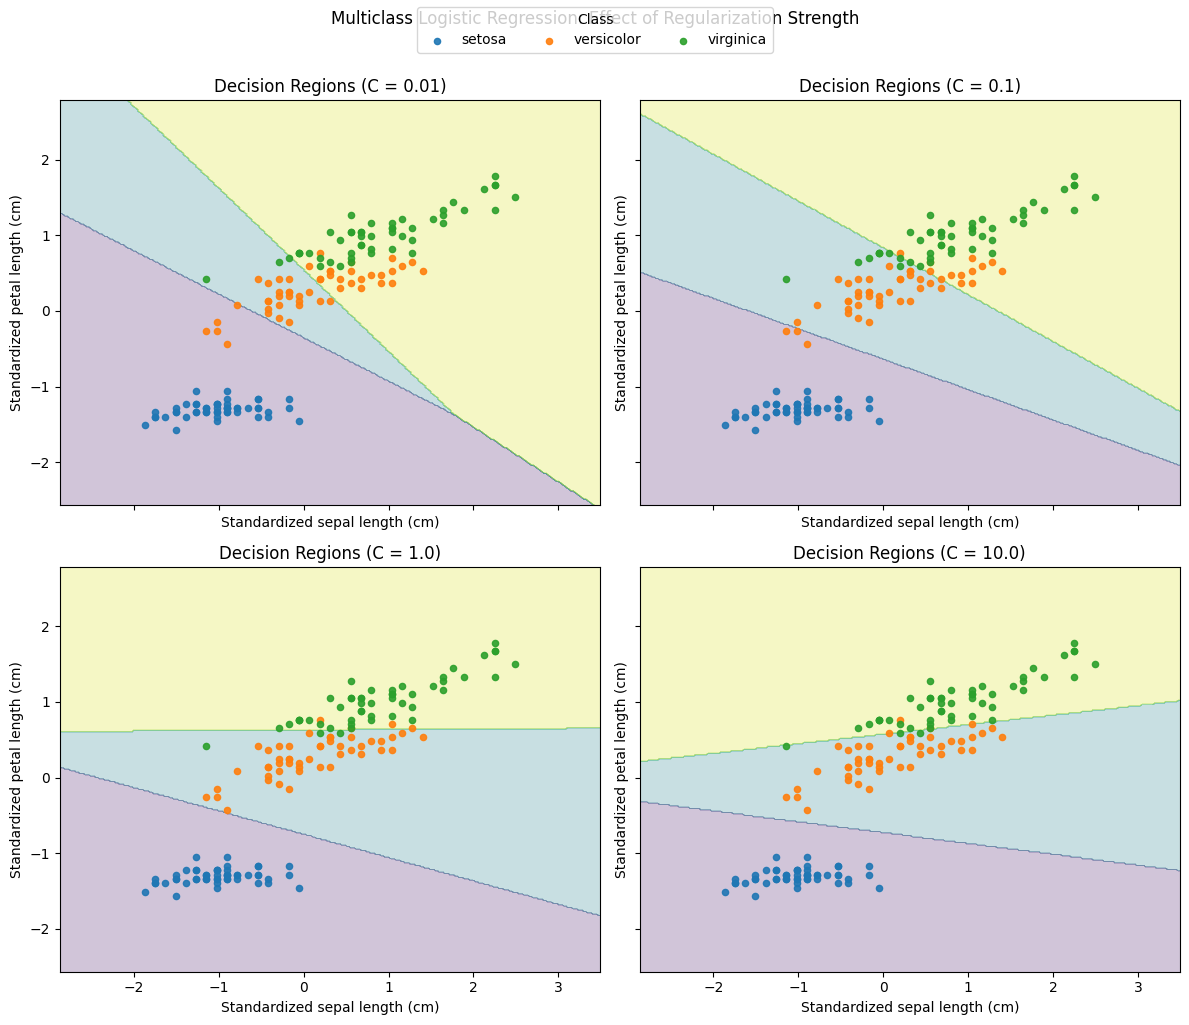

In [30]:
# ----- assumes you already have: X2, y_iris, iris_target_names, iris_feature_names, f1, f2 -----

# Mesh grid for decision regions
x_min, x_max = X2[:, 0].min() - 1, X2[:, 0].max() + 1
y_min, y_max = X2[:, 1].min() - 1, X2[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))
grid = np.c_[xx.ravel(), yy.ravel()]

# Different regularization strengths to compare
C_values = [0.01, 0.1, 1.0, 10.0]  # small C = strong reg, large C = weak reg

fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True, sharey=True)
axes = axes.ravel()

for ax, C in zip(axes, C_values):
    model = LogisticRegression(
        solver="lbfgs",
        C=C,
        max_iter=500
    )
    model.fit(X2, y_iris)

    Z = model.predict(grid).reshape(xx.shape)

    # Decision regions
    ax.contourf(xx, yy, Z, alpha=0.25)

    # Points per class (legend handled once later)
    for cls, name in enumerate(iris_target_names):
        mask = (y_iris == cls)
        ax.scatter(X2[mask, 0], X2[mask, 1], label=name, alpha=0.9, s=20)

    ax.set_title(f"Decision Regions (C = {C})")
    ax.set_xlabel(f"Standardized {iris_feature_names[f1]}")
    ax.set_ylabel(f"Standardized {iris_feature_names[f2]}")

# Build one shared legend (avoid duplicates)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="Class", loc="upper center", ncol=len(iris_target_names))

fig.suptitle("Multiclass Logistic Regression: Effect of Regularization Strength", y=1.02)
plt.tight_layout()
plt.show()



## 6. L1 Regularization → Feature Selection (Concept in Code)

We now use **all 4 Iris features** and fit multinomial logistic regression with **L1 penalty**.

In sklearn, **smaller `C`** means **stronger regularization** (roughly, `C = 1/λ`).


In [31]:

X_full = StandardScaler().fit_transform(X_iris_raw)

log_reg_l1 = LogisticRegression(
    penalty="l1",
    solver="saga",
    C=0.08,
    max_iter=5000,
    random_state=42
)
log_reg_l1.fit(X_full, y_iris)

coef = log_reg_l1.coef_  # (n_classes, n_features)

print("L1-regularized coefficients (rows=classes, cols=features):")
for c_idx, c_name in enumerate(iris_target_names):
    row = ", ".join([f"{iris_feature_names[j]}={coef[c_idx, j]: .4f}" for j in range(coef.shape[1])])
    print(f"  Class {c_name}: {row}")

# Identify effectively-dropped features: coefficient ~ 0 for ALL classes
eps = 1e-4
dropped = np.all(np.abs(coef) < eps, axis=0)

print("\nEffectively dropped features (all-class |coef| < 1e-4):")
for j, name in enumerate(iris_feature_names):
    print(f"  {name}: {'DROPPED' if dropped[j] else 'kept'}")


L1-regularized coefficients (rows=classes, cols=features):
  Class setosa: sepal length (cm)= 0.0000, sepal width (cm)= 0.0000, petal length (cm)=-1.8315, petal width (cm)= 0.0000
  Class versicolor: sepal length (cm)= 0.0000, sepal width (cm)=-0.2173, petal length (cm)= 0.0000, petal width (cm)= 0.0000
  Class virginica: sepal length (cm)= 0.0000, sepal width (cm)= 0.0000, petal length (cm)= 0.0000, petal width (cm)= 1.4645

Effectively dropped features (all-class |coef| < 1e-4):
  sepal length (cm): DROPPED
  sepal width (cm): kept
  petal length (cm): kept
  petal width (cm): kept



### Optional: Compare Against No Regularization

This shows how coefficients change when we remove the penalty.


In [32]:

log_reg_none = LogisticRegression(
    penalty=None,
    solver="lbfgs",
    max_iter=500
)
log_reg_none.fit(X_full, y_iris)

coef_none = log_reg_none.coef_

print("No-regularization coefficients (rows=classes, cols=features):")
for c_idx, c_name in enumerate(iris_target_names):
    row = ", ".join([f"{iris_feature_names[j]}={coef_none[c_idx, j]: .4f}" for j in range(coef_none.shape[1])])
    print(f"  Class {c_name}: {row}")


No-regularization coefficients (rows=classes, cols=features):
  Class setosa: sepal length (cm)=-5.4954, sepal width (cm)= 4.0061, petal length (cm)=-9.0337, petal width (cm)=-8.2037
  Class versicolor: sepal length (cm)= 3.7596, sepal width (cm)=-0.5440, petal length (cm)=-3.8115, petal width (cm)=-2.8863
  Class virginica: sepal length (cm)= 1.7358, sepal width (cm)=-3.4621, petal length (cm)= 12.8452, petal width (cm)= 11.0900



## Summary

- **Linear regression**: predicts continuous targets, minimizes **L2 loss**
- **Loss surfaces** show how optimization behaves in parameter space
- **GD vs SGD**: GD is smoother; SGD is noisier but can be faster per step
- **Logistic regression**: predicts class probabilities; minimizes **cross-entropy (log loss)**
- **Decision boundaries** in logistic regression are **linear** in the chosen feature space
- **L1 regularization** can force coefficients to **zero** → conceptual feature selection (LASSO-like effect)
